# Exp5 IIITD-CLI  Notebook A1: Disk-Saved Balanced Augmentation + CNN+Attention 
**Experiment:** 5-backbone  5-protocol cross-sensor PAD on IIITD-CLI (25 total runs)
**This notebook trains combos 1-12 of 25.** Run Notebook A2 for combos 13-25.



## 1. Imports

In [1]:
# ---------------------------------------------------------------------------
# Imports. cv2 added for the disk-based augmentation recipes (CLAHE, JPEG-sim,
# noise, blur, sharpen). WeightedRandomSampler removed \u2014 balancing is now
# achieved physically (disk-saved oversampled copies), not via sampler weights.
# ---------------------------------------------------------------------------
import os
import re
import json
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as T

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kwargs): return it

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## 2. Config + Output Folders

In [2]:
# ---------------------------------------------------------------------------
# Config. NEW: 'target_train_size' now applies to EVERY protocol (not just
# Combined), and 'max_copies_per_original' caps per-image oversampling to
# avoid pathological duplication of rare low-count subjects.
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD")
RAW_ROOT     = PROJECT_ROOT / 'Data' / 'Raw' / 'IIITD_Contact_Lens_Iris_DB'
COGENT_ROOT  = RAW_ROOT / 'Cogent Scanner'
VISTA_ROOT   = RAW_ROOT / 'Vista Scanner'

EXP_NAME     = 'Exp5_IIITD_CrossSensor_5Protocol'
EXP_DIR      = PROJECT_ROOT / 'Experiments' / EXP_NAME
MODELS_DIR   = EXP_DIR / 'outputs' / 'models'
METRICS_DIR  = EXP_DIR / 'outputs' / 'metrics'
FIGURES_DIR  = EXP_DIR / 'outputs' / 'figures'
LOGS_DIR     = EXP_DIR / 'outputs' / 'logs'
SPLITS_DIR   = EXP_DIR / 'outputs' / 'splits'
PREDS_DIR    = EXP_DIR / 'outputs' / 'predictions'
DET_DIR      = FIGURES_DIR / 'det_curves'
AUG_ROOT     = EXP_DIR / 'outputs' / 'augmented_images'   # NEW: disk-saved augmented images

for folder in [MODELS_DIR, METRICS_DIR, FIGURES_DIR, LOGS_DIR, SPLITS_DIR, PREDS_DIR, DET_DIR, AUG_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO, format='%(asctime)s | %(message)s',
    handlers=[logging.FileHandler(str(LOGS_DIR / 'training.log')), logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

CONFIG = {
    'seed':          SEED,
    'img_size':      224,
    'batch_size':    32,
    'epochs':        50,
    'lr':            1e-4,
    'weight_decay':  1e-4,
    'dropout':       0.4,
    'early_stop':    25,
    'force_retrain': False,
    # NEW: augmentation / balancing config (applies to ALL 5 protocols)
    'target_train_size':        22000,  # minimum effective train size, per protocol
    'max_copies_per_original':  40,     # cap on oversampling multiplier per source image
    'jpeg_quality':              92,    # quality when saving augmented JPEGs
}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
CLASS_FOLDERS = {'Colored': 1, 'Normal': 0}
EXCLUDED_CLASS = 'Transparent'

EXPECTED_COUNTS = {
    'Cogent': {'total': 3466, 'live': 1163, 'spoof': 2303},
    'Vista':  {'total': 3015, 'live': 1000, 'spoof': 2015},
}

# NEW: apbs_densenet121 replaced by efficientnet_b0. Rationale: PBS is removed
# entirely, and every backbone now shares the SAME CBAM Attention Gate design,
# so 'apbs_densenet121' would be an exact architectural duplicate of
# 'densenet121' with nothing to differentiate it. EfficientNet-B0 gives a
# genuinely distinct 5th architecture (compound-scaled MBConv blocks).
BACKBONE_NAMES = ['resnet18', 'densenet121', 'vgg16', 'mobilenetv2', 'efficientnet_b0']
PROTOCOL_NAMES = ['P1_Cogent_to_Cogent', 'P2_Vista_to_Vista',
                  'P3_Cogent_to_Vista', 'P4_Vista_to_Cogent', 'P5_Combined']

print('Config ready \u2713')
print(f'Cogent root : {COGENT_ROOT}  (exists: {COGENT_ROOT.exists()})')
print(f'Vista root  : {VISTA_ROOT}   (exists: {VISTA_ROOT.exists()})')
print(f'Output root : {EXP_DIR}')
print(f"Target train size (per protocol, min): {CONFIG['target_train_size']:,}")
print(f"Backbones (attention gate, no PBS)   : {BACKBONE_NAMES}")


Config ready ✓
Cogent root : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IIITD_Contact_Lens_Iris_DB\Cogent Scanner  (exists: True)
Vista root  : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IIITD_Contact_Lens_Iris_DB\Vista Scanner   (exists: True)
Output root : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol
Target train size (per protocol, min): 22,000
Backbones (attention gate, no PBS)   : ['resnet18', 'densenet121', 'vgg16', 'mobilenetv2', 'efficientnet_b0']


## 3. Subject-Wise Raw-Folder Parser

In [3]:
# ---------------------------------------------------------------------------
# Raw-folder parser (unchanged) \u2014 Transparent excluded, Vista Left/Right merged.
# ---------------------------------------------------------------------------
def parse_cogent(root):
    records = []
    if not root.exists():
        print(f'  [MISSING] {root}'); return pd.DataFrame(records)
    subject_folders = sorted([d for d in os.listdir(root) if (root / d).is_dir()])
    for subj in subject_folders:
        subj_path = root / subj
        for class_name, label in CLASS_FOLDERS.items():
            class_dir = subj_path / class_name
            if not class_dir.exists(): continue
            for fname in os.listdir(class_dir):
                if Path(fname).suffix.lower() not in VALID_EXTS: continue
                records.append({
                    'path': str(class_dir / fname), 'sensor': 'Cogent',
                    'subject_id_raw': subj, 'subject_uid': f'Cogent_{subj}',
                    'class_name': class_name, 'label': label,
                    'eye_side': 'NA', 'filename': fname,
                })
    return pd.DataFrame(records)

def parse_vista(root):
    records = []
    if not root.exists():
        print(f'  [MISSING] {root}'); return pd.DataFrame(records)
    subject_folders = sorted([d for d in os.listdir(root) if (root / d).is_dir()])
    for subj in subject_folders:
        subj_path = root / subj
        for class_name, label in CLASS_FOLDERS.items():
            class_dir = subj_path / class_name
            if not class_dir.exists(): continue
            for eye_side in ['Left', 'Right']:
                eye_dir = class_dir / eye_side
                if not eye_dir.exists(): continue
                for fname in os.listdir(eye_dir):
                    if Path(fname).suffix.lower() not in VALID_EXTS: continue
                    records.append({
                        'path': str(eye_dir / fname), 'sensor': 'Vista',
                        'subject_id_raw': subj, 'subject_uid': f'Vista_{subj}',
                        'class_name': class_name, 'label': label,
                        'eye_side': eye_side, 'filename': fname,
                    })
    return pd.DataFrame(records)

print('Parsing Cogent Scanner (Colored + Normal only, Transparent excluded)...')
cogent_df = parse_cogent(COGENT_ROOT)
print('Parsing Vista Scanner (Colored + Normal only, Transparent excluded, Left+Right merged)...')
vista_df  = parse_vista(VISTA_ROOT)

print('\n' + '=' * 60)
print('  DISCOVERED vs EXPECTED COUNT AUDIT')
print('=' * 60)
for sensor_name, df in [('Cogent', cogent_df), ('Vista', vista_df)]:
    n_total = len(df); n_live = int((df['label']==0).sum()); n_spoof = int((df['label']==1).sum())
    n_subj  = df['subject_id_raw'].nunique()
    exp = EXPECTED_COUNTS[sensor_name]
    print(f'\n  {sensor_name}:')
    print(f'    Subjects discovered : {n_subj}  (expected ~101)')
    print(f'    Total   : discovered={n_total:5d}  expected={exp["total"]:5d}  diff={n_total-exp["total"]:+d}')
    print(f'    Live    : discovered={n_live:5d}  expected={exp["live"]:5d}  diff={n_live-exp["live"]:+d}')
    print(f'    Spoof   : discovered={n_spoof:5d}  expected={exp["spoof"]:5d}  diff={n_spoof-exp["spoof"]:+d}')

if len(cogent_df) == 0 or len(vista_df) == 0:
    print('\n[STOP] One or both sensor dataframes are EMPTY. Check RAW_ROOT paths above.')
else:
    print('\nParser completed \u2713')
    master_raw = pd.concat([cogent_df, vista_df], ignore_index=True)
    master_raw.to_csv(SPLITS_DIR / 'master_raw_index.csv', index=False)
    print(f'Saved -> {SPLITS_DIR}/master_raw_index.csv  ({len(master_raw)} rows)')


Parsing Cogent Scanner (Colored + Normal only, Transparent excluded)...
Parsing Vista Scanner (Colored + Normal only, Transparent excluded, Left+Right merged)...

  DISCOVERED vs EXPECTED COUNT AUDIT

  Cogent:
    Subjects discovered : 101  (expected ~101)
    Total   : discovered= 2323  expected= 3466  diff=-1143
    Live    : discovered= 1163  expected= 1163  diff=+0
    Spoof   : discovered= 1160  expected= 2303  diff=-1143

  Vista:
    Subjects discovered : 101  (expected ~101)
    Total   : discovered= 2005  expected= 3015  diff=-1010
    Live    : discovered= 1000  expected= 1000  diff=+0
    Spoof   : discovered= 1005  expected= 2015  diff=-1010

Parser completed ✓
Saved -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp5_IIITD_CrossSensor_5Protocol\outputs\splits/master_raw_index.csv  (4328 rows)


## 4. Build 5 Subject-Wise Protocols (RAW/natural, pre-balancing)

In [4]:
# ---------------------------------------------------------------------------
# Build the 5 subject-wise protocols (unchanged) \u2014 RAW/natural distribution.
# Balancing + augmentation happens in the NEXT cell, applied only to train_df.
# ---------------------------------------------------------------------------
def subject_wise_split(df, test_size, seed):
    if len(df) == 0: return df.copy(), df.copy()
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(df, groups=df['subject_uid']))
    return df.iloc[idx_a].reset_index(drop=True), df.iloc[idx_b].reset_index(drop=True)

def build_protocol(name, train_df, val_df, test_df):
    train_subj = set(train_df['subject_uid']); val_subj = set(val_df['subject_uid']); test_subj = set(test_df['subject_uid'])
    overlap_tv = train_subj & val_subj; overlap_tt = train_subj & test_subj; overlap_vt = val_subj & test_subj
    if overlap_tv or overlap_tt or overlap_vt:
        raise AssertionError(f'[{name}] SUBJECT LEAKAGE! train\u2229val={len(overlap_tv)} train\u2229test={len(overlap_tt)} val\u2229test={len(overlap_vt)}')
    return {'train_df': train_df, 'val_df': val_df, 'test_df': test_df}

def load_or_build_protocol(name, builder_fn):
    train_p = SPLITS_DIR / f'{name}_train.csv'; val_p = SPLITS_DIR / f'{name}_val.csv'; test_p = SPLITS_DIR / f'{name}_test.csv'
    if train_p.exists() and val_p.exists() and test_p.exists():
        print(f'  [LOAD] {name} \u2014 using existing manifest CSVs')
        return {'train_df': pd.read_csv(train_p), 'val_df': pd.read_csv(val_p), 'test_df': pd.read_csv(test_p)}
    protocol = builder_fn()
    protocol['train_df'].to_csv(train_p, index=False)
    protocol['val_df'].to_csv(val_p, index=False)
    protocol['test_df'].to_csv(test_p, index=False)
    print(f'  [BUILD] {name} \u2014 saved new manifest CSVs')
    return protocol

def _p1():
    tr, tmp = subject_wise_split(cogent_df, test_size=0.30, seed=SEED)
    va, te  = subject_wise_split(tmp, test_size=0.50, seed=SEED)
    return build_protocol('P1_Cogent_to_Cogent', tr, va, te)

def _p2():
    tr, tmp = subject_wise_split(vista_df, test_size=0.30, seed=SEED)
    va, te  = subject_wise_split(tmp, test_size=0.50, seed=SEED)
    return build_protocol('P2_Vista_to_Vista', tr, va, te)

def _p3():
    tr, va = subject_wise_split(cogent_df, test_size=0.15, seed=SEED)
    te     = vista_df.reset_index(drop=True)
    return build_protocol('P3_Cogent_to_Vista', tr, va, te)

def _p4():
    tr, va = subject_wise_split(vista_df, test_size=0.15, seed=SEED)
    te     = cogent_df.reset_index(drop=True)
    return build_protocol('P4_Vista_to_Cogent', tr, va, te)

def _p5():
    c_tr, c_tmp = subject_wise_split(cogent_df, test_size=0.30, seed=SEED)
    c_va, c_te  = subject_wise_split(c_tmp, test_size=0.50, seed=SEED)
    v_tr, v_tmp = subject_wise_split(vista_df, test_size=0.30, seed=SEED)
    v_va, v_te  = subject_wise_split(v_tmp, test_size=0.50, seed=SEED)
    tr = pd.concat([c_tr, v_tr], ignore_index=True)
    va = pd.concat([c_va, v_va], ignore_index=True)
    te = pd.concat([c_te, v_te], ignore_index=True)
    return build_protocol('P5_Combined', tr, va, te)

print('Building/loading 5 subject-wise protocols...\n')
protocols = {}
protocols['P1_Cogent_to_Cogent'] = load_or_build_protocol('P1_Cogent_to_Cogent', _p1)
protocols['P2_Vista_to_Vista']   = load_or_build_protocol('P2_Vista_to_Vista',   _p2)
protocols['P3_Cogent_to_Vista']  = load_or_build_protocol('P3_Cogent_to_Vista',  _p3)
protocols['P4_Vista_to_Cogent']  = load_or_build_protocol('P4_Vista_to_Cogent',  _p4)
protocols['P5_Combined']         = load_or_build_protocol('P5_Combined',         _p5)

print('\n' + '=' * 70)
print('  PROTOCOL SUMMARY (subject-disjoint, zero-leakage assertions passed)')
print('=' * 70)
print(f'{"Protocol":22s} {"Train N":>9} {"Val N":>7} {"Test N":>8} {"Tr.Subj":>8} {"Val.Subj":>9} {"Te.Subj":>8}')
for name, p in protocols.items():
    print(f'{name:22s} {len(p["train_df"]):>9} {len(p["val_df"]):>7} {len(p["test_df"]):>8} '
          f'{p["train_df"]["subject_uid"].nunique():>8} {p["val_df"]["subject_uid"].nunique():>9} '
          f'{p["test_df"]["subject_uid"].nunique():>8}')
print('=' * 70)
print('\nAll 5 protocols built with zero subject leakage \u2713  (these are RAW/natural train sets)')


Building/loading 5 subject-wise protocols...

  [LOAD] P1_Cogent_to_Cogent — using existing manifest CSVs
  [LOAD] P2_Vista_to_Vista — using existing manifest CSVs
  [LOAD] P3_Cogent_to_Vista — using existing manifest CSVs
  [LOAD] P4_Vista_to_Cogent — using existing manifest CSVs
  [LOAD] P5_Combined — using existing manifest CSVs

  PROTOCOL SUMMARY (subject-disjoint, zero-leakage assertions passed)
Protocol                 Train N   Val N   Test N  Tr.Subj  Val.Subj  Te.Subj
P1_Cogent_to_Cogent         1622     331      370       70        15       16
P2_Vista_to_Vista           1385     300      320       70        15       16
P3_Cogent_to_Vista          1960     363     2005       85        16      101
P4_Vista_to_Cogent          1685     320     2323       85        16      101
P5_Combined                 3007     631      690      140        30       32

All 5 protocols built with zero subject leakage ✓  (these are RAW/natural train sets)


## 5. Augmentation Recipes (13 iris-safe transforms)

In [5]:
# ---------------------------------------------------------------------------
# Deterministic, iris-safe augmentation recipes. 13 recipes cycled per
# subject-stratum. Each recipe is intentionally MILD (no extreme rotation,
# no severe crop, no vertical flip, no unrealistic color distortion) to avoid
# destroying genuine iris/lens PAD evidence.
# ---------------------------------------------------------------------------
N_RECIPES = 13

def apply_augmentation(img_pil, recipe_idx, rng):
    img = np.array(img_pil.convert('RGB'))
    recipe = recipe_idx % N_RECIPES

    if recipe == 0:      # small rotation (+/- 7 deg)
        angle = rng.uniform(-7, 7)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    elif recipe == 1:    # horizontal flip
        img = cv2.flip(img, 1)
    elif recipe == 2:    # small translation
        tx = rng.uniform(-0.05, 0.05) * img.shape[1]
        ty = rng.uniform(-0.05, 0.05) * img.shape[0]
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REFLECT)
    elif recipe == 3:    # mild scale zoom
        scale = rng.uniform(0.95, 1.05)
        h, w = img.shape[:2]
        img_r = cv2.resize(img, (max(1,int(w*scale)), max(1,int(h*scale))))
        img = cv2.resize(img_r, (w, h))
    elif recipe == 4:    # brightness up
        img = np.clip(img.astype(np.float32) * 1.15, 0, 255).astype(np.uint8)
    elif recipe == 5:    # brightness down
        img = np.clip(img.astype(np.float32) * 0.85, 0, 255).astype(np.uint8)
    elif recipe == 6:    # contrast adjust
        mean = img.mean()
        img = np.clip((img.astype(np.float32) - mean) * 1.15 + mean, 0, 255).astype(np.uint8)
    elif recipe == 7:    # gamma adjust
        gamma = float(rng.choice([0.85, 1.15]))
        img = np.clip(255 * (img / 255.0) ** gamma, 0, 255).astype(np.uint8)
    elif recipe == 8:    # mild gaussian noise
        noise = rng.normal(0, 5, img.shape)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    elif recipe == 9:    # mild gaussian blur
        img = cv2.GaussianBlur(img, (3, 3), 0)
    elif recipe == 10:   # mild sharpen (unsharp mask)
        blur = cv2.GaussianBlur(img, (0, 0), 3)
        img = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    elif recipe == 11:   # mild CLAHE contrast enhancement
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l2 = clahe.apply(l)
        img = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2RGB)
    elif recipe == 12:   # JPEG compression simulation
        _, enc = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                              [cv2.IMWRITE_JPEG_QUALITY, 70])
        dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)

    return Image.fromarray(img)

RECIPE_NAMES = [
    'rotate_small', 'flip_horizontal', 'translate_small', 'scale_zoom',
    'brightness_up', 'brightness_down', 'contrast_adjust', 'gamma_adjust',
    'gaussian_noise', 'gaussian_blur', 'sharpen', 'clahe_enhance', 'jpeg_compress_sim',
]
print(f'{N_RECIPES} augmentation recipes defined: {RECIPE_NAMES}')


13 augmentation recipes defined: ['rotate_small', 'flip_horizontal', 'translate_small', 'scale_zoom', 'brightness_up', 'brightness_down', 'contrast_adjust', 'gamma_adjust', 'gaussian_noise', 'gaussian_blur', 'sharpen', 'clahe_enhance', 'jpeg_compress_sim']


## 6. Generate/Load Balanced, Disk-Saved Augmented Training Sets (ALL 5 protocols)

**This is the core new step.** Physically writes augmented JPEGs to disk,
balanced by Sensor \u00d7 Class \u00d7 Subject, targeting 22,000+ per protocol.
Fully resumable \u2014 already-generated protocols are skipped on re-run.


In [6]:
# ---------------------------------------------------------------------------
# generate_augmented_train_set(): disk-saved, balanced, resumable.
#
# Balancing logic:
#   P1/P2/P3/P4 (single-sensor train data) -> 2-way strata (label only)
#   P5_Combined (spans both sensors)       -> 4-way strata (sensor, label)
#
# Within EACH stratum, the quota is split EQUALLY across the unique subjects
# present in that stratum -> this is the SUBJECT-WISE balancing layer on top
# of the sensor/class balancing.
#
# Resumable: if the manifest CSV + a '_GENERATION_COMPLETE.flag' file already
# exist for a protocol, generation is skipped entirely (fast reload).
# ---------------------------------------------------------------------------
def generate_augmented_train_set(train_df, protocol_name, config):
    img_out_dir    = AUG_ROOT / protocol_name
    manifest_path  = SPLITS_DIR / f'{protocol_name}_train_augmented_manifest.csv'
    done_flag_path = img_out_dir / '_GENERATION_COMPLETE.flag'
    img_out_dir.mkdir(parents=True, exist_ok=True)

    if manifest_path.exists() and done_flag_path.exists():
        print(f'  [LOAD] {protocol_name}: augmented manifest already exists, loading...')
        return pd.read_csv(manifest_path)

    print(f'  [GENERATE] {protocol_name}: building balanced augmented training set...')
    df = train_df.copy()

    if protocol_name == 'P5_Combined':
        df['_stratum'] = df['sensor'] + '_' + df['label'].astype(str)
        strata_mode = '4-way (sensor x label)'
    else:
        df['_stratum'] = df['label'].astype(str)
        strata_mode = '2-way (label only)'

    strata_names   = df['_stratum'].unique()
    n_strata       = len(strata_names)
    stratum_counts = df['_stratum'].value_counts()
    quota_per_stratum = max(config['target_train_size'] // n_strata, stratum_counts.max())

    print(f'    Balancing mode      : {strata_mode}')
    print(f'    Strata found        : {list(strata_names)}')
    print(f'    Quota per stratum   : {quota_per_stratum:,}')
    print(f'    Target total (min)  : {quota_per_stratum * n_strata:,}')

    manifest_records = []
    aug_counter = 0
    n_capped_subjects = 0

    for stratum in strata_names:
        stratum_df = df[df['_stratum'] == stratum]
        subjects    = stratum_df['subject_uid'].unique()
        n_subjects  = len(subjects)
        quota_per_subject = max(1, quota_per_stratum // max(n_subjects, 1))

        for subj in subjects:
            subj_imgs = stratum_df[stratum_df['subject_uid'] == subj].reset_index(drop=True)
            n_orig    = len(subj_imgs)

            # Always include every original image (is_augmented=False)
            for _, row in subj_imgs.iterrows():
                manifest_records.append({
                    'path': row['path'], 'source_path': row['path'],
                    'subject_uid': subj, 'sensor': row['sensor'], 'label': int(row['label']),
                    'protocol': protocol_name, 'augmentation_id': -1,
                    'augmentation_type': 'original', 'is_augmented': False,
                })

            n_needed = quota_per_subject - n_orig
            if n_needed <= 0:
                continue

            # Cap oversampling multiplier to avoid pathological duplication
            max_copies = config['max_copies_per_original'] * max(n_orig, 1)
            if n_needed > max_copies:
                n_capped_subjects += 1
                n_needed = max_copies

            rng = np.random.default_rng(seed=abs(hash((protocol_name, stratum, subj))) % (2**32))
            for k in range(n_needed):
                src_row  = subj_imgs.iloc[k % n_orig]
                recipe_idx = k % N_RECIPES
                try:
                    img     = Image.open(src_row['path']).convert('RGB')
                    aug_img = apply_augmentation(img, recipe_idx, rng)
                except Exception:
                    continue
                aug_counter += 1
                fname    = f"{subj}_{Path(src_row['path']).stem}_aug{aug_counter}.jpg"
                out_path = img_out_dir / fname
                aug_img.save(out_path, quality=config['jpeg_quality'])
                manifest_records.append({
                    'path': str(out_path), 'source_path': src_row['path'],
                    'subject_uid': subj, 'sensor': src_row['sensor'], 'label': int(src_row['label']),
                    'protocol': protocol_name, 'augmentation_id': aug_counter,
                    'augmentation_type': RECIPE_NAMES[recipe_idx], 'is_augmented': True,
                })

    manifest_df = pd.DataFrame(manifest_records)
    manifest_df.to_csv(manifest_path, index=False)
    done_flag_path.touch()

    print(f'    Generated {aug_counter:,} new augmented images')
    print(f'    Final manifest size: {len(manifest_df):,}')
    if n_capped_subjects > 0:
        print(f'    [WARNING] {n_capped_subjects} subjects hit the '
              f'max_copies_per_original cap ({config["max_copies_per_original"]}x) '
              f'\u2014 their quota could not be fully reached.')
    return manifest_df


print('Generating/loading balanced augmented training sets for all 5 protocols...')
print('(One-time cost per protocol; resumable if interrupted)\n')

augmented_manifests = {}
for protocol_name in PROTOCOL_NAMES:
    train_df_raw = protocols[protocol_name]['train_df']
    augmented_manifests[protocol_name] = generate_augmented_train_set(
        train_df_raw, protocol_name, CONFIG
    )

print('\n' + '=' * 80)
print('  AUGMENTED TRAINING SET SUMMARY (all 5 protocols)')
print('=' * 80)
for protocol_name, manifest in augmented_manifests.items():
    n_total = len(manifest)
    n_orig  = int((~manifest['is_augmented']).sum())
    n_aug   = int(manifest['is_augmented'].sum())
    if protocol_name == 'P5_Combined':
        breakdown = manifest.groupby(['sensor', 'label']).size().to_dict()
    else:
        breakdown = manifest.groupby('label').size().to_dict()
    print(f'\n  {protocol_name}:')
    print(f'    Total (orig+aug) : {n_total:,}  (original={n_orig:,}, augmented={n_aug:,})')
    print(f'    Stratum breakdown: {breakdown}')


Generating/loading balanced augmented training sets for all 5 protocols...
(One-time cost per protocol; resumable if interrupted)

  [LOAD] P1_Cogent_to_Cogent: augmented manifest already exists, loading...
  [LOAD] P2_Vista_to_Vista: augmented manifest already exists, loading...
  [LOAD] P3_Cogent_to_Vista: augmented manifest already exists, loading...
  [LOAD] P4_Vista_to_Cogent: augmented manifest already exists, loading...
  [GENERATE] P5_Combined: building balanced augmented training set...
    Balancing mode      : 4-way (sensor x label)
    Strata found        : ['Cogent_1', 'Cogent_0', 'Vista_1', 'Vista_0']
    Quota per stratum   : 5,500
    Target total (min)  : 22,000
    Generated 18,824 new augmented images
    Final manifest size: 21,831

  AUGMENTED TRAINING SET SUMMARY (all 5 protocols)

  P1_Cogent_to_Cogent:
    Total (orig+aug) : 21,980  (original=1,622, augmented=20,358)
    Stratum breakdown: {0: 10990, 1: 10990}

  P2_Vista_to_Vista:
    Total (orig+aug) : 21,961 

## 7. Visual Augmentation Audit

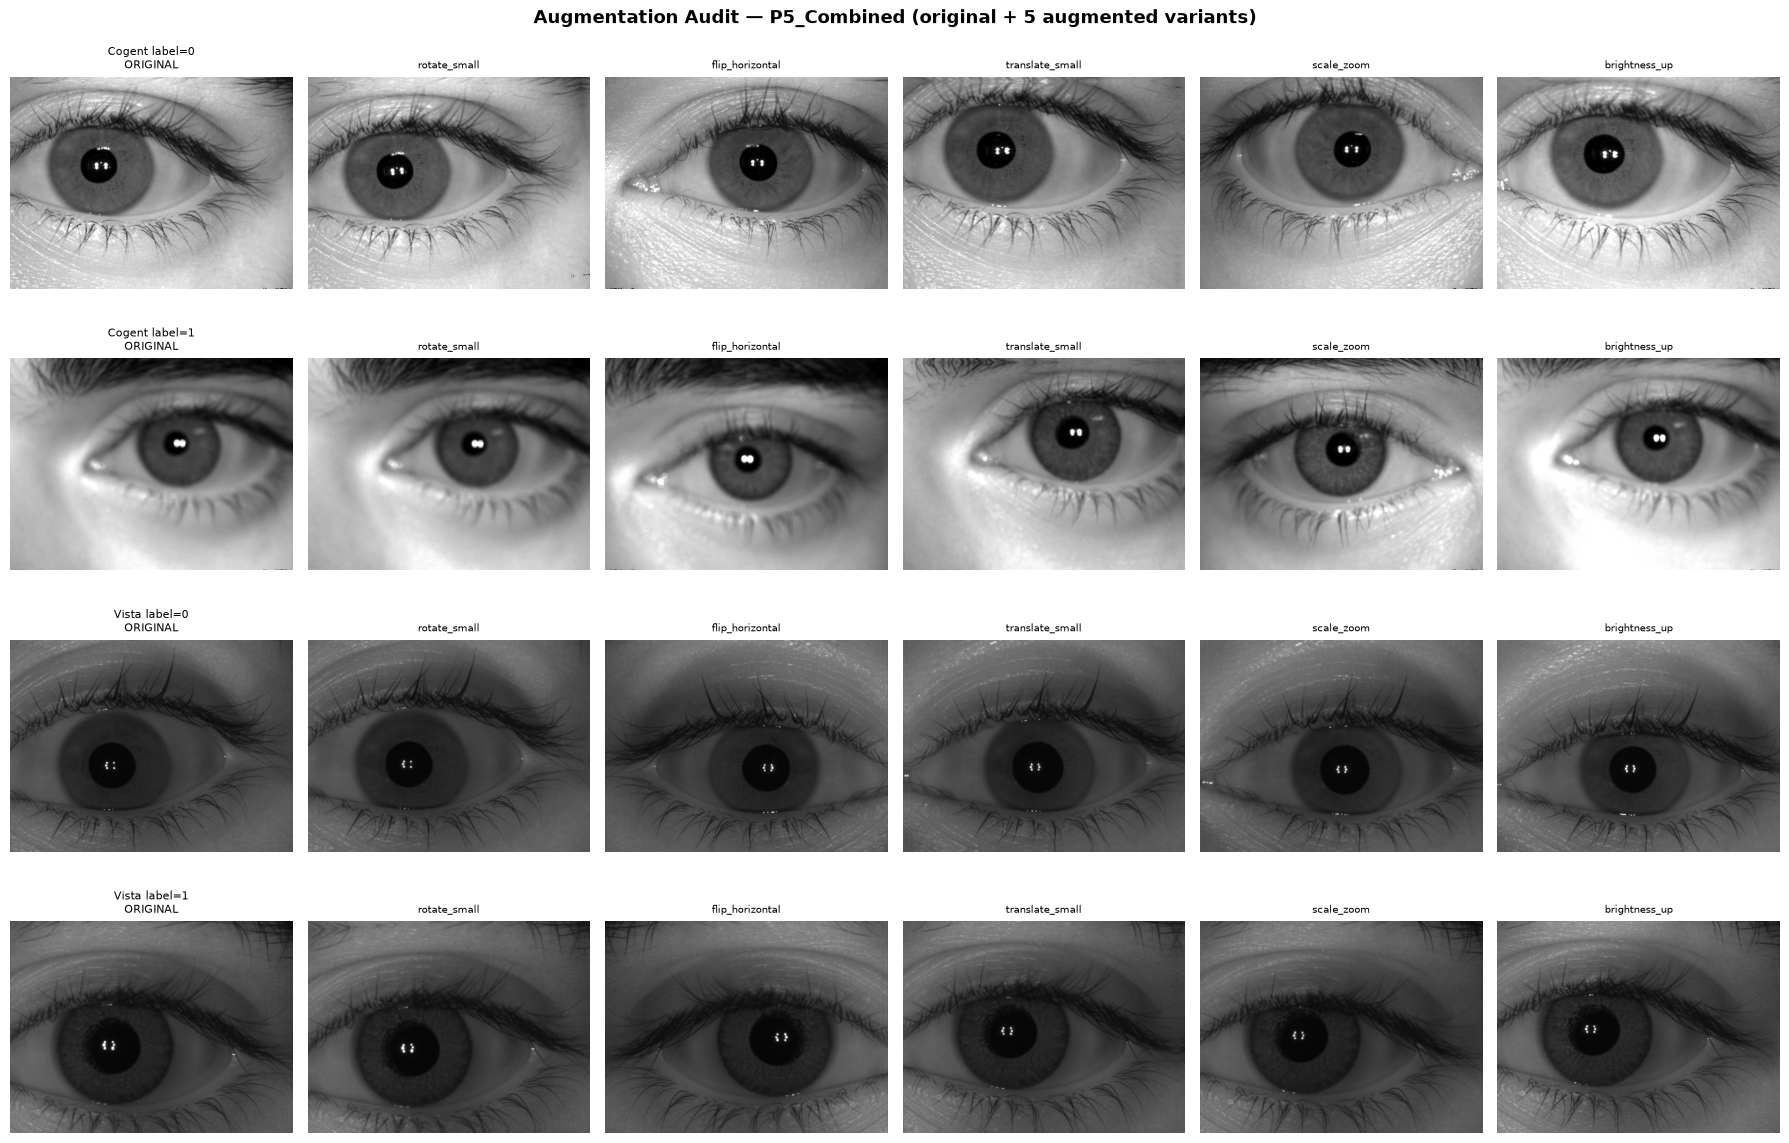

Saved -> augmentation_audit.png


In [7]:
# ---------------------------------------------------------------------------
# Visual augmentation audit: original vs several augmented copies, one
# example per sensor per class, so the augmentation quality can be sanity-
# checked before spending GPU time training on it.
# ---------------------------------------------------------------------------
audit_protocol = 'P5_Combined'
audit_manifest = augmented_manifests[audit_protocol]

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle(f'Augmentation Audit \u2014 {audit_protocol} (original + 5 augmented variants)',
             fontsize=13, fontweight='bold')

row_i = 0
for sensor in ['Cogent', 'Vista']:
    for label in [0, 1]:
        subset = audit_manifest[
            (audit_manifest['sensor'] == sensor) & (audit_manifest['label'] == label)
        ]
        orig_rows = subset[~subset['is_augmented']]
        if len(orig_rows) == 0:
            row_i += 1; continue
        sample_subj = orig_rows.iloc[0]['subject_uid']
        subj_rows   = subset[subset['subject_uid'] == sample_subj]
        orig_row    = subj_rows[~subj_rows['is_augmented']].iloc[0]
        aug_rows    = subj_rows[subj_rows['is_augmented']].head(5)

        img0 = Image.open(orig_row['path']).convert('RGB')
        axes[row_i][0].imshow(img0)
        axes[row_i][0].set_title(f'{sensor} label={label}\nORIGINAL', fontsize=8)
        axes[row_i][0].axis('off')

        for j in range(5):
            if j < len(aug_rows):
                r = aug_rows.iloc[j]
                img_a = Image.open(r['path']).convert('RGB')
                axes[row_i][j+1].imshow(img_a)
                axes[row_i][j+1].set_title(r['augmentation_type'], fontsize=7)
            axes[row_i][j+1].axis('off')
        row_i += 1

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'augmentation_audit.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> augmentation_audit.png')


## 8. Dataset Class + Transforms

In [8]:
# ---------------------------------------------------------------------------
# Dataset classes.
# TRAIN: reads from the pre-generated augmented manifest (path column already
#        points to either an original or a saved-to-disk augmented JPEG).
#        Only a LIGHT on-the-fly transform is applied (resize+normalize) since
#        the heavy visual diversity is already baked into the physical files
#        \u2014 this also keeps per-epoch CPU cost low.
# VAL/TEST: always read from the ORIGINAL untouched images, never augmented.
# ---------------------------------------------------------------------------
IMG_SIZE = (CONFIG['img_size'], CONFIG['img_size'])

train_transform_light = T.Compose([
    T.Resize(IMG_SIZE), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    T.Resize(IMG_SIZE), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class IrisPADDataset(Dataset):
    def __init__(self, df, transform, path_col='path'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.path_col = path_col
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row[self.path_col]).convert('RGB')
        image = self.transform(image)
        return image, int(row['label'])

print('IrisPADDataset + transforms ready \u2713  (train=light transform on pre-augmented disk images)')


IrisPADDataset + transforms ready ✓  (train=light transform on pre-augmented disk images)


## 9. Model Factory — CBAM Attention Gate on ALL 5 Backbones (No PBS)

In [9]:
# ---------------------------------------------------------------------------
# CBAM Attention Gate (channel + spatial) \u2014 IDENTICAL design applied to
# ALL 5 backbones. NO PBS anywhere in this notebook.
# ---------------------------------------------------------------------------

class ChannelAttention(nn.Module):
    # Squeeze-and-excitation-style channel attention: learns which feature
    # channels are most discriminative for live/spoof classification.
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, max(channels // reduction, 8), 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(channels // reduction, 8), channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttentionGate(nn.Module):
    # Spatial attention: learns WHICH region of the feature map to focus on
    # (e.g. iris ring vs sclera/background).
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAMAttentionGate(nn.Module):
    # Convolutional Block Attention Module (Woo et al., 2018): channel
    # attention followed by spatial attention. This exact module is
    # instantiated identically for every one of the 5 backbones below.
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttentionGate()
    def forward(self, x):
        x = x * self.channel_att(x)
        x = x * self.spatial_att(x)
        return x


class AttentionCNNModel(nn.Module):
    # CNN backbone stem -> CBAM Attention Gate -> GAP -> classifier.
    # NO pixel-level supervision head (PBS removed per your instruction).
    def __init__(self, backbone_stem, feat_channels, num_classes=2, dropout=0.4):
        super().__init__()
        self.stem = backbone_stem
        self.attention_gate = CBAMAttentionGate(feat_channels)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        feat = self.stem(x)
        feat = self.attention_gate(feat)
        pooled = self.global_pool(feat).flatten(1)
        return self.classifier(pooled)


def build_attention_model(backbone_name, dropout=0.4):
    if backbone_name == 'resnet18':
        net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                p.requires_grad = False
        stem, feat_channels = nn.Sequential(*list(net.children())[:-2]), 512

    elif backbone_name == 'densenet121':
        net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'denseblock4' not in name and 'norm5' not in name and 'classifier' not in name:
                p.requires_grad = False
        stem, feat_channels = net.features, 1024

    elif backbone_name == 'vgg16':
        net = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for i, layer in enumerate(net.features):
            if i < len(net.features) - 4:
                for p in layer.parameters():
                    p.requires_grad = False
        stem, feat_channels = net.features, 512

    elif backbone_name == 'mobilenetv2':
        net = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'features.18' not in name and 'features.17' not in name:
                p.requires_grad = False
        stem, feat_channels = net.features, 1280

    elif backbone_name == 'efficientnet_b0':
        net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for i, layer in enumerate(net.features):
            if i < 6:
                for p in layer.parameters():
                    p.requires_grad = False
        stem, feat_channels = net.features, 1280

    else:
        raise ValueError(f'Unknown backbone: {backbone_name}')

    return AttentionCNNModel(stem, feat_channels, dropout=dropout)


def iso_metrics(y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    APCER = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    BPCER = FP / (TN + FP) if (TN + FP) > 0 else 0.0
    result = {'APCER': APCER, 'BPCER': BPCER, 'ACER': (APCER + BPCER) / 2,
              'ACC': (TP + TN) / (TP + TN + FP + FN), 'CM': cm}
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.abs(fnr - fpr))
        result['EER'] = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
        result['AUC'] = float(auc(fpr, tpr))
    return result


def plot_det_curve(y_true, y_prob, combo_id, save_dir):
    thresholds = np.linspace(0.01, 0.99, 300)
    apcers, bpcers = [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        TN, FP, FN, TP = cm.ravel()
        apcers.append(FN / (TP + FN) if (TP + FN) > 0 else 0.0)
        bpcers.append(FP / (TN + FP) if (TN + FP) > 0 else 0.0)
    apcers = np.array(apcers) * 100; bpcers = np.array(bpcers) * 100
    eer_idx = int(np.argmin(np.abs(apcers - bpcers)))
    eer_approx = (apcers[eer_idx] + bpcers[eer_idx]) / 2

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(bpcers, apcers, color='#7B1FA2', lw=2.2, label='DET curve')
    ax.scatter([bpcers[eer_idx]], [apcers[eer_idx]], s=80, color='red', zorder=5,
               label=f'EER (approx) = {eer_approx:.2f}%')
    max_v = max(apcers.max(), bpcers.max(), 1.0)
    ax.plot([0, max_v], [0, max_v], 'k--', lw=1, alpha=0.5, label='EER diagonal')
    ax.set(xlabel='BPCER (%)', ylabel='APCER (%)', title=f'DET Curve \u2014 {combo_id}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f'{combo_id}_det.png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    return eer_approx

print('CBAM Attention Gate + build_attention_model() + iso_metrics + DET curve defined \u2713')
print('NO PBS anywhere in this notebook.')


CBAM Attention Gate + build_attention_model() + iso_metrics + DET curve defined ✓
NO PBS anywhere in this notebook.


## 10. Training Function (Resumable)

In [10]:
# ---------------------------------------------------------------------------
# train_one_combo(): resumable. Uses the pre-generated, disk-saved, balanced
# augmented manifest as the training set (already 22k+ and sensor/class/
# subject-balanced) \u2014 NO sampler needed, since balancing is now physical.
# Loss: plain CrossEntropyLoss (class weights kept as a safety net, should be
# close to neutral since the data is already balanced on disk).
# ---------------------------------------------------------------------------
def train_one_combo(backbone_name, protocol_name, train_manifest, val_df, test_df, config):
    combo_id  = f'{backbone_name}_{protocol_name}'
    save_path = MODELS_DIR  / f'{combo_id}.pth'
    json_path = METRICS_DIR / f'{combo_id}.json'

    if json_path.exists() and save_path.exists() and not config['force_retrain']:
        with open(json_path) as f:
            result = json.load(f)
        print(f'[SKIP] {combo_id} already done '
              f'(ACER={result["ACER"]:.2f}%  EER={result.get("EER","?")}%  AUC={result["AUC"]:.4f})')
        return result

    print('\n' + '#' * 60)
    print(f'#  {combo_id}')
    print('#' * 60)
    logger.info(f'=== Starting: {combo_id} ===')

    train_ds = IrisPADDataset(train_manifest, train_transform_light, path_col='path')
    val_ds   = IrisPADDataset(val_df,  eval_transform, path_col='path')
    test_ds  = IrisPADDataset(test_df, eval_transform, path_col='path')

    train_loader = DataLoader(train_ds, config['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   config['batch_size'], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  config['batch_size'], shuffle=False, num_workers=0)

    live_n, spoof_n = (train_manifest.label==0).sum(), (train_manifest.label==1).sum()
    total = len(train_manifest)
    class_weights = torch.tensor([
        total / (2 * max(live_n, 1)), total / (2 * max(spoof_n, 1))
    ], dtype=torch.float).to(DEVICE)
    print(f'  Effective train size: {total:,}  (class_weights \u2248 {class_weights.cpu().numpy().round(3)}, should be near 1.0 since balanced on disk)')

    model = build_attention_model(backbone_name, dropout=config['dropout']).to(DEVICE)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'], weight_decay=config['weight_decay']
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss, patience = float('inf'), 0

    print(f'\n{"Ep":>4} {"TrLoss":>9} {"TrAcc":>8} {"VaLoss":>9} {"VaAcc":>8}')
    print('-' * 45)
    for epoch in range(1, config['epochs'] + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item() * imgs.size(0)
            tc += (logits.argmax(1) == lbls).sum().item()
            tt += imgs.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                logits = model(imgs)
                loss = criterion(logits, lbls)
                vl += loss.item() * imgs.size(0)
                vc += (logits.argmax(1) == lbls).sum().item()
                vt += imgs.size(0)

        tl /= tt; vl /= vt; ta = 100*tc/tt; va = 100*vc/vt
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        scheduler.step()

        if vl < best_val_loss:
            best_val_loss, patience = vl, 0
            torch.save(model.state_dict(), save_path)
            marker = ' <- best'
        else:
            patience += 1
            marker = ''
        print(f'{epoch:>4} {tl:>9.4f} {ta:>7.2f}% {vl:>9.4f} {va:>7.2f}%{marker}')
        if patience >= config['early_stop']:
            print(f'Early stop at epoch {epoch}')
            break

    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    fig.suptitle(f'{combo_id} - Training Curves', fontsize=11, fontweight='bold')
    axes[0].plot(ep, history['train_loss'], 'b-o', ms=2, label='Train')
    axes[0].plot(ep, history['val_loss'],   'r-o', ms=2, label='Val')
    axes[0].set(title='Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history['train_acc'], 'b-o', ms=2, label='Train')
    axes[1].plot(ep, history['val_acc'],   'r-o', ms=2, label='Val')
    axes[1].set(title='Accuracy', ylim=[0,105]); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{combo_id}_curves.png', dpi=100, bbox_inches='tight')
    plt.close(fig)

    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    test_paths = test_df['path'].tolist()
    with torch.no_grad():
        for imgs, lbls in test_loader:
            logits = model(imgs.to(DEVICE))
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(lbls.numpy())
            all_probs.extend(probs.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    m = iso_metrics(all_labels, all_preds, all_probs)
    eer_det = plot_det_curve(all_labels, all_probs, combo_id, DET_DIR)

    preds_df = pd.DataFrame({
        'path': test_paths[:len(all_labels)], 'label': all_labels,
        'pred': all_preds, 'prob': all_probs,
    })
    preds_df.to_csv(PREDS_DIR / f'{combo_id}_predictions.csv', index=False)

    result_row = {
        'Backbone': backbone_name, 'Protocol': protocol_name,
        'Accuracy': round(m['ACC']*100, 2), 'APCER': round(m['APCER']*100, 2),
        'BPCER':    round(m['BPCER']*100, 2), 'ACER': round(m['ACER']*100, 2),
        'EER':      round(m['EER']*100, 2),   'AUC':  round(m['AUC'], 4),
        'Effective_train_size': total,
        'Model path': str(save_path), 'Epochs_trained': len(history['train_loss']),
    }
    with open(json_path, 'w') as f:
        json.dump(result_row, f, indent=2)

    logger.info(f'{combo_id} -> ACC:{m["ACC"]*100:.2f}% ACER:{m["ACER"]*100:.2f}% EER:{m["EER"]*100:.2f}% AUC:{m["AUC"]:.4f}')
    print(f'\n{combo_id} complete. ACC={m["ACC"]*100:.2f}% ACER={m["ACER"]*100:.2f}% '
          f'EER={m["EER"]*100:.2f}% AUC={m["AUC"]:.4f}')
    return result_row

print('train_one_combo() defined (resumable, disk-balanced, CBAM attention, no PBS) \u2713')


train_one_combo() defined (resumable, disk-balanced, CBAM attention, no PBS) ✓


## 11. Full 25-Combo List (A1 trains combos 1-12)

In [11]:
# ---------------------------------------------------------------------------
# Full 25-combo list. A1 trains combos[0:12], A2 trains combos[12:25].
# ---------------------------------------------------------------------------
ALL_25_COMBOS = []
for backbone in BACKBONE_NAMES:
    for protocol in PROTOCOL_NAMES:
        ALL_25_COMBOS.append((backbone, protocol))

print(f'Total combos defined: {len(ALL_25_COMBOS)}')
print('\nFull combo order:')
for i, (b, p) in enumerate(ALL_25_COMBOS, 1):
    marker = ' <- A1 ends here' if i == 12 else ''
    print(f'  {i:2d}. {b:20s} / {p}{marker}')


Total combos defined: 25

Full combo order:
   1. resnet18             / P1_Cogent_to_Cogent
   2. resnet18             / P2_Vista_to_Vista
   3. resnet18             / P3_Cogent_to_Vista
   4. resnet18             / P4_Vista_to_Cogent
   5. resnet18             / P5_Combined
   6. densenet121          / P1_Cogent_to_Cogent
   7. densenet121          / P2_Vista_to_Vista
   8. densenet121          / P3_Cogent_to_Vista
   9. densenet121          / P4_Vista_to_Cogent
  10. densenet121          / P5_Combined
  11. vgg16                / P1_Cogent_to_Cogent
  12. vgg16                / P2_Vista_to_Vista <- A1 ends here
  13. vgg16                / P3_Cogent_to_Vista
  14. vgg16                / P4_Vista_to_Cogent
  15. vgg16                / P5_Combined
  16. mobilenetv2          / P1_Cogent_to_Cogent
  17. mobilenetv2          / P2_Vista_to_Vista
  18. mobilenetv2          / P3_Cogent_to_Vista
  19. mobilenetv2          / P4_Vista_to_Cogent
  20. mobilenetv2          / P5_Combined
  21. ef

## 12. Train Combos 1-12

**resnet18**  [P1,P2,P3,P4,P5] + **densenet121** [P1,P2,P3,P4,P5] + **vgg16** [P1,P2]


In [12]:
a1_combos = ALL_25_COMBOS[0:12]
print(f'Notebook A1 will train {len(a1_combos)} combos:\n')
for i, (b, p) in enumerate(a1_combos, 1):
    print(f'  {i:2d}. {b} / {p}')

a1_results = []
for backbone_name, protocol_name in a1_combos:
    proto = protocols[protocol_name]
    train_manifest = augmented_manifests[protocol_name]
    result = train_one_combo(
        backbone_name, protocol_name,
        train_manifest, proto['val_df'], proto['test_df'],
        CONFIG
    )
    a1_results.append(result)

print(f'\n\nA1 complete: {len(a1_results)} / {len(a1_combos)} combos done.')


2026-07-10 16:25:33,912 | === Starting: resnet18_P1_Cogent_to_Cogent ===


Notebook A1 will train 12 combos:

   1. resnet18 / P1_Cogent_to_Cogent
   2. resnet18 / P2_Vista_to_Vista
   3. resnet18 / P3_Cogent_to_Vista
   4. resnet18 / P4_Vista_to_Cogent
   5. resnet18 / P5_Combined
   6. densenet121 / P1_Cogent_to_Cogent
   7. densenet121 / P2_Vista_to_Vista
   8. densenet121 / P3_Cogent_to_Vista
   9. densenet121 / P4_Vista_to_Cogent
  10. densenet121 / P5_Combined
  11. vgg16 / P1_Cogent_to_Cogent
  12. vgg16 / P2_Vista_to_Vista

############################################################
#  resnet18_P1_Cogent_to_Cogent
############################################################
  Effective train size: 21,980  (class_weights ≈ [1. 1.], should be near 1.0 since balanced on disk)

  Ep    TrLoss    TrAcc    VaLoss    VaAcc
---------------------------------------------
   1    0.0424   98.64%    0.0194   99.40% <- best
   2    0.0029   99.93%    0.0977   97.58%
   3    0.0022   99.93%    0.0120   99.40% <- best
   4    0.0011   99.96%    0.1576   96.07%
   5

2026-07-10 19:46:58,523 | resnet18_P1_Cogent_to_Cogent -> ACC:96.22% ACER:3.77% EER:3.24% AUC:0.9950
2026-07-10 19:46:58,593 | === Starting: resnet18_P2_Vista_to_Vista ===



resnet18_P1_Cogent_to_Cogent complete. ACC=96.22% ACER=3.77% EER=3.24% AUC=0.9950

############################################################
#  resnet18_P2_Vista_to_Vista
############################################################
  Effective train size: 21,961  (class_weights ≈ [1.001 0.999], should be near 1.0 since balanced on disk)

  Ep    TrLoss    TrAcc    VaLoss    VaAcc
---------------------------------------------
   1    0.0305   99.22%    0.0001  100.00% <- best
   2    0.0017   99.95%    0.0002  100.00%
   3    0.0009   99.97%    0.0000  100.00% <- best
   4    0.0020   99.95%    0.0000  100.00%
   5    0.0004   99.99%    0.0000  100.00%
   6    0.0000  100.00%    0.0000  100.00% <- best
   7    0.0004   99.98%    0.0000  100.00% <- best
   8    0.0012   99.98%    0.0000  100.00%
   9    0.0002   99.99%    0.0000  100.00% <- best
  10    0.0000  100.00%    0.0000  100.00% <- best
  11    0.0000  100.00%    0.0000  100.00% <- best
  12    0.0001  100.00%    0.0000  100

2026-07-10 23:25:01,442 | resnet18_P2_Vista_to_Vista -> ACC:97.81% ACER:2.19% EER:1.88% AUC:0.9984
2026-07-10 23:25:01,461 | === Starting: resnet18_P3_Cogent_to_Vista ===


...


densenet121_P5_Combined complete. ACC=97.39% ACER=2.60% EER=1.16% AUC=0.9967

############################################################
#  vgg16_P1_Cogent_to_Cogent
############################################################
  Effective train size: 21,980  (class_weights ≈ [1. 1.], should be near 1.0 since balanced on disk)

  Ep    TrLoss    TrAcc    VaLoss    VaAcc
---------------------------------------------
   1    0.0774   96.75%    0.0127   99.40% <- best
   2    0.0014   99.95%    0.0179   99.09%
   3    0.0025   99.93%    0.0383   99.09%
   4    0.0011   99.98%    0.0664   98.49%
   5    0.0003   99.99%    0.0160   99.70%
   6    0.0045   99.92%    0.0011  100.00% <- best
   7    0.0017   99.96%    0.0241   98.79%
   8    0.0020   99.96%    0.0341   98.79%
   9    0.0000  100.00%    0.0176   99.09%
  10    0.0000  100.00%    0.0114   99.70%
  11    0.0000  100.00%    0.0088   99.70%
  12    0.0000  100.00%    0.0067   99.70%
  13    0.0000  100.00%    0.0067   99.70%
  14

2026-07-12 23:49:03,554 | vgg16_P1_Cogent_to_Cogent -> ACC:97.03% ACER:2.96% EER:2.43% AUC:0.9944
2026-07-12 23:49:03,570 | === Starting: vgg16_P2_Vista_to_Vista ===



vgg16_P1_Cogent_to_Cogent complete. ACC=97.03% ACER=2.96% EER=2.43% AUC=0.9944

############################################################
#  vgg16_P2_Vista_to_Vista
############################################################
  Effective train size: 21,961  (class_weights ≈ [1.001 0.999], should be near 1.0 since balanced on disk)

  Ep    TrLoss    TrAcc    VaLoss    VaAcc
---------------------------------------------
   1    0.0607   97.90%    0.0001  100.00% <- best
   2    0.0001  100.00%    0.0037  100.00%
   3    0.0009   99.97%    0.0122   99.67%
   4    0.0008   99.98%    0.0000  100.00% <- best
   5    0.0000  100.00%    0.0004  100.00%
   6    0.0023   99.94%    0.0000  100.00% <- best
   7    0.0000  100.00%    0.0000  100.00%
   8    0.0000  100.00%    0.0000  100.00%
   9    0.0000  100.00%    0.0000  100.00%
  10    0.0000  100.00%    0.0000  100.00%
  11    0.0000  100.00%    0.0000  100.00%
  12    0.0000  100.00%    0.0000  100.00%
  13    0.0000  100.00%    0.0000

2026-07-13 05:51:26,037 | vgg16_P2_Vista_to_Vista -> ACC:99.06% ACER:0.94% EER:2.50% AUC:0.9993



vgg16_P2_Vista_to_Vista complete. ACC=99.06% ACER=0.94% EER=2.50% AUC=0.9993


A1 complete: 12 / 12 combos done.


## 13. A1 Partial Summary (Combos 1-12)

In [14]:
a1_summary_df = pd.DataFrame(a1_results)
a1_summary_df.to_csv(METRICS_DIR / 'a1_summary_combos_1_12.csv', index=False)


print(a1_summary_df[['Backbone','Protocol','Accuracy','APCER','BPCER','ACER','EER','AUC','Effective_train_size']].to_string(index=False))
print('=' * 100)
print(f'\nSaved -> {METRICS_DIR}/a1_summary_combos_1_12.csv')
print(f'Checkpoints -> {MODELS_DIR}')




   Backbone            Protocol  Accuracy  APCER  BPCER  ACER  EER    AUC  Effective_train_size
   resnet18 P1_Cogent_to_Cogent     96.22   6.99   0.54  3.77 3.24 0.9950                 21980
   resnet18   P2_Vista_to_Vista     97.81   4.38   0.00  2.19 1.88 0.9984                 21961
   resnet18  P3_Cogent_to_Vista     99.55   0.70   0.20  0.45 0.40 0.9996                 21930
   resnet18  P4_Vista_to_Cogent     93.67   2.07  10.58  6.32 5.25 0.9923                 21885
   resnet18         P5_Combined     96.52   6.36   0.58  3.47 2.61 0.9980                 21831
densenet121 P1_Cogent_to_Cogent     97.84   3.76   0.54  2.15 1.08 0.9983                 21980
densenet121   P2_Vista_to_Vista     98.12   3.75   0.00  1.88 0.31 0.9985                 21961
densenet121  P3_Cogent_to_Vista     99.35   1.29   0.00  0.65 0.55 0.9999                 21930
densenet121  P4_Vista_to_Cogent     94.58  10.52   0.34  5.43 4.65 0.9894                 21885
densenet121         P5_Combined     97.3